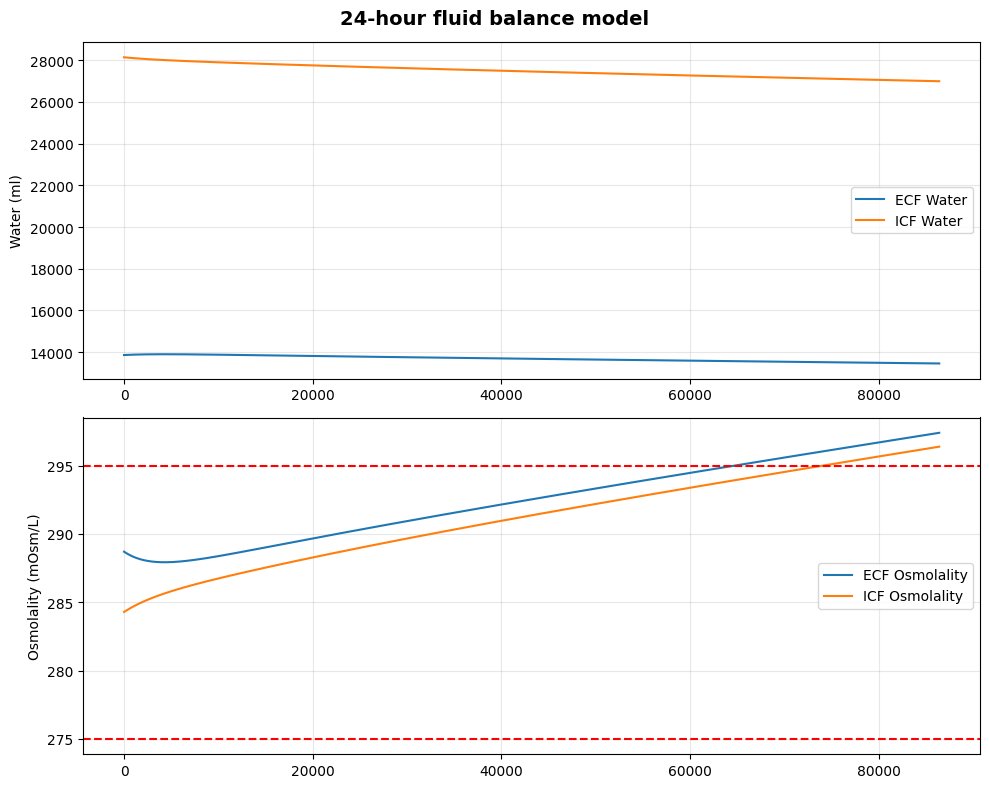

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initialise model variables
water = 42000
salt = 117
water_ECF = 0.33 * water
water_ICF = 0.67 * water
osm_ECF = 34.2 * salt
osm_ICF = 8000
min_osmo = 275
max_osmo = 295

# Set control parameters
runtime = 86400

# Set model parameters
ktrans = 0.01
kv=0.4
R_k=2
R_n=2
AVPthre=285
Umin=400/runtime
Umax=1500/runtime
water_loss = 750
water_loss = water_loss / 86400
water_ECF_data = np.empty(runtime + 1)
water_ICF_data = np.empty(runtime + 1)
osm_ECF_data = np.empty(runtime + 1)
osm_ICF_data = np.empty(runtime + 1)
osmo_ECF_data = np.empty(runtime + 1)
osmo_ICF_data = np.empty(runtime + 1)
AVP_data = np.zeros(runtime + 1)

# Initialise recording arrays
water_ECF_data[0] = water_ECF
water_ICF_data[0] = water_ICF
osm_ECF_data[0] = osm_ECF
osm_ICF_data[0] = osm_ICF
osmo_ECF_data[0] = osm_ECF / (water_ECF / 1000)
osmo_ICF_data[0] = osm_ICF / (water_ICF / 1000)


# Run model loop
for i in range(1, runtime + 1):
    #vesopressin
    if osmo_ECF_data[i-1] > AVPthre:
        AVP_data[i] = kv*(osmo_ECF_data[i-1] - AVPthre)
    else:       AVP_data[i] = 0
    Rv=AVP_data[i]**R_n/(AVP_data[i]**R_n+R_k**R_n)
    Uw=Umin+(1-Rv)*(Umax-Umin)

    osmo_ECF = osm_ECF / (water_ECF / 1000)
    osmo_ICF = osm_ICF / (water_ICF / 1000)
    water_trans = ktrans * (osmo_ECF - osmo_ICF)
    water_ECF = water_ECF + water_trans - water_loss - Uw
    if water_ECF < 0: water_ECF = 0
    water_ICF = water_ICF - water_trans
    osm_ECF = osm_ECF + 0
    water_ECF_data[i] = water_ECF
    water_ICF_data[i] = water_ICF
    osm_ECF_data[i] = osm_ECF
    osm_ICF_data[i] = osm_ICF
    osmo_ECF_data[i] = osmo_ECF
    osmo_ICF_data[i] = osmo_ICF
    
# Plot results
fig,axes = plt.subplots(2,1,figsize=(10,8))
fig.suptitle("24-hour fluid balance model", fontsize=14, fontweight="bold")

axes[0].plot(water_ECF_data, label='ECF Water')
axes[0].plot(water_ICF_data, label='ICF Water')
axes[0].set_ylabel('Water (ml)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(osmo_ECF_data, label='ECF Osmolality')
axes[1].plot(osmo_ICF_data, label='ICF Osmolality')
axes[1].set_ylabel('Osmolality (mOsm/L)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=min_osmo,color='r', linestyle='--', label='Min normal Osmolality')
axes[1].axhline(y=max_osmo,color='r', linestyle='--', label='Max normal Osmolality')

plt.tight_layout()
plt.show()

normal range for osmolarity is 275-295,
next we are going to drink some water
if we keep constant water intake (like injection...)

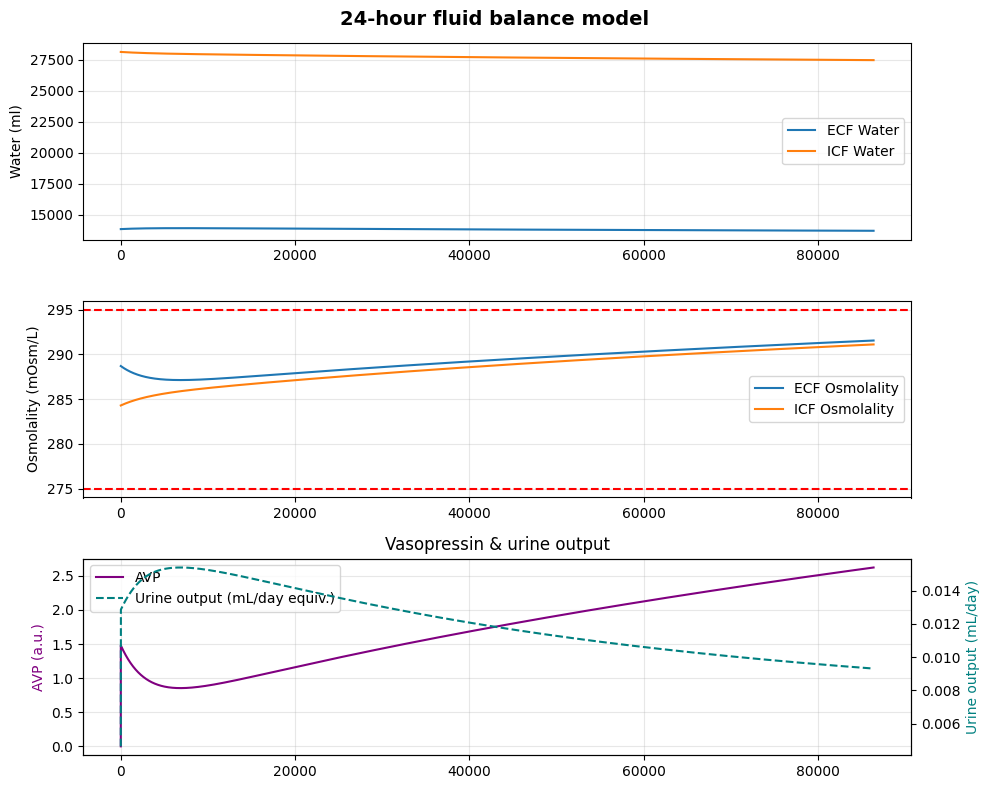

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Initialise model variables
water = 42000
salt = 117
water_ECF = 0.33 * water
water_ICF = 0.67 * water
osm_ECF = 34.2 * salt
osm_ICF = 8000
min_osmo = 275
max_osmo = 295

# Set control parameters
runtime = 86400

# Set model parameters
ktrans = 0.01
kv=0.4
R_k=2
R_n=2
AVPthre=285
Umin=400/runtime
Umax=1500/runtime
water_loss = 750
water_loss = water_loss / 86400
water_intake=1000
water_intake = water_intake / 86400
water_ECF_data = np.empty(runtime + 1)
water_ICF_data = np.empty(runtime + 1)
osm_ECF_data = np.empty(runtime + 1)
osm_ICF_data = np.empty(runtime + 1)
osmo_ECF_data = np.empty(runtime + 1)
osmo_ICF_data = np.empty(runtime + 1)
urine_data = np.zeros(runtime + 1)
AVP_data = np.zeros(runtime + 1)

# Initialise recording arrays
water_ECF_data[0] = water_ECF
water_ICF_data[0] = water_ICF
osm_ECF_data[0] = osm_ECF
osm_ICF_data[0] = osm_ICF
osmo_ECF_data[0] = osm_ECF / (water_ECF / 1000)
osmo_ICF_data[0] = osm_ICF / (water_ICF / 1000)
AVP_data[0] = 0
urine_data[0] = Umin


# Run model loop
for i in range(1, runtime + 1):
    #vesopressin
    if osmo_ECF_data[i-1] > AVPthre:
        AVP_data[i] = kv*(osmo_ECF_data[i-1] - AVPthre)
    else:       AVP_data[i] = 0
    Rv=AVP_data[i]**R_n/(AVP_data[i]**R_n+R_k**R_n)
    urine_data[i]=Umin+(1-Rv)*(Umax-Umin)

    osmo_ECF = osm_ECF / (water_ECF / 1000)
    osmo_ICF = osm_ICF / (water_ICF / 1000)
    water_trans = ktrans * (osmo_ECF - osmo_ICF)
    water_ECF = water_ECF + water_trans - water_loss - urine_data[i] + water_intake
    if water_ECF < 0: water_ECF = 0
    water_ICF = water_ICF - water_trans
    osm_ECF = osm_ECF + 0
    water_ECF_data[i] = water_ECF
    water_ICF_data[i] = water_ICF
    osm_ECF_data[i] = osm_ECF
    osm_ICF_data[i] = osm_ICF
    osmo_ECF_data[i] = osmo_ECF
    osmo_ICF_data[i] = osmo_ICF
    
# Plot results
fig,axes = plt.subplots(3,1,figsize=(10,8))
fig.suptitle("24-hour fluid balance model", fontsize=14, fontweight="bold")

axes[0].plot(water_ECF_data, label='ECF Water')
axes[0].plot(water_ICF_data, label='ICF Water')
axes[0].set_ylabel('Water (ml)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(osmo_ECF_data, label='ECF Osmolality')
axes[1].plot(osmo_ICF_data, label='ICF Osmolality')
axes[1].set_ylabel('Osmolality (mOsm/L)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=min_osmo,color='r', linestyle='--', label='Min normal Osmolality')
axes[1].axhline(y=max_osmo,color='r', linestyle='--', label='Max normal Osmolality')

ax = axes[2]
ax2 = ax.twinx()
ax.plot(AVP_data, color="purple", label="AVP")
ax2.plot(urine_data, color="teal", linestyle="--", label="Urine output (mL/day equiv.)")
ax.set_ylabel("AVP (a.u.)", color="purple")
ax2.set_ylabel("Urine output (mL/day)", color="teal")
ax.set_title("Vasopressin & urine output")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

however, injecting water is impossible.
lets assume we drink each meal and in the evening.

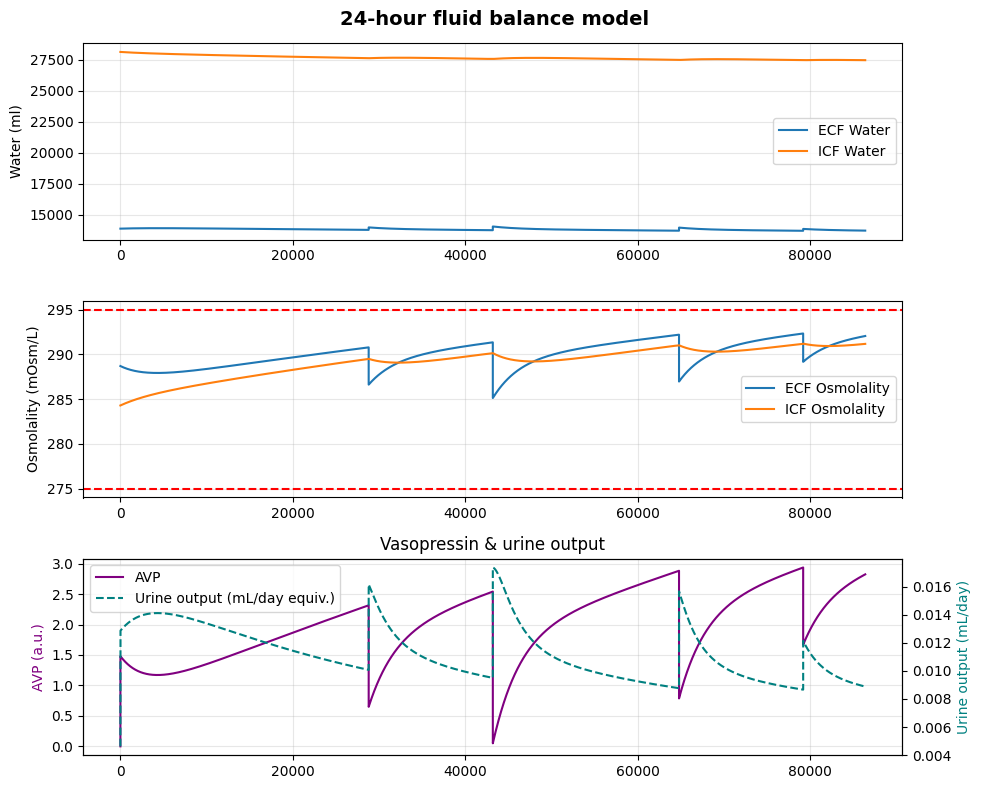

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Initialise model variables
water = 42000
salt = 117
water_ECF = 0.33 * water
water_ICF = 0.67 * water
osm_ECF = 34.2 * salt
osm_ICF = 8000
min_osmo = 275
max_osmo = 295

# Set control parameters
runtime = 86400

# Set model parameters
ktrans = 0.01
kv=0.4
R_k=2
R_n=2
AVPthre=285
Umin=400/runtime
Umax=1500/runtime
water_loss = 750
water_loss = water_loss / 86400

water_ECF_data = np.empty(runtime + 1)
water_ICF_data = np.empty(runtime + 1)
osm_ECF_data = np.empty(runtime + 1)
osm_ICF_data = np.empty(runtime + 1)
osmo_ECF_data = np.empty(runtime + 1)
osmo_ICF_data = np.empty(runtime + 1)
AVP_data = np.zeros(runtime + 1)
urine_data = np.zeros(runtime + 1)

# Initialise recording arrays
water_ECF_data[0] = water_ECF
water_ICF_data[0] = water_ICF
osm_ECF_data[0] = osm_ECF
osm_ICF_data[0] = osm_ICF
osmo_ECF_data[0] = osm_ECF / (water_ECF / 1000)
osmo_ICF_data[0] = osm_ICF / (water_ICF / 1000)
urine_data[0] = Umin
AVP_data[0] = 0

#drinking events
drinking={8*3600:200,
          12*3600:300,
          18*3600:250,
          22*3600:150}

# Run model loop
for i in range(1, runtime + 1):

    # Check for drinking events
    if i in drinking.keys():
        water_intake = drinking[i]
    else:
        water_intake = 0

    #vesopressin
    if osmo_ECF_data[i-1] > AVPthre:
        AVP_data[i] = kv*(osmo_ECF_data[i-1] - AVPthre)
    else:       AVP_data[i] = 0
    Rv=AVP_data[i]**R_n/(AVP_data[i]**R_n+R_k**R_n)
    Uw=Umin+(1-Rv)*(Umax-Umin)

    osmo_ECF = osm_ECF / (water_ECF / 1000)
    osmo_ICF = osm_ICF / (water_ICF / 1000)
    water_trans = ktrans * (osmo_ECF - osmo_ICF)
    water_ECF = water_ECF + water_trans - water_loss - Uw + water_intake
    if water_ECF < 0: water_ECF = 0
    water_ICF = water_ICF - water_trans
    osm_ECF = osm_ECF + 0
    water_ECF_data[i] = water_ECF
    water_ICF_data[i] = water_ICF
    osm_ECF_data[i] = osm_ECF
    osm_ICF_data[i] = osm_ICF
    osmo_ECF_data[i] = osmo_ECF
    osmo_ICF_data[i] = osmo_ICF
    urine_data[i]=Uw
    
# Plot results
fig,axes = plt.subplots(3,1,figsize=(10,8))
fig.suptitle("24-hour fluid balance model", fontsize=14, fontweight="bold")

axes[0].plot(water_ECF_data, label='ECF Water')
axes[0].plot(water_ICF_data, label='ICF Water')
axes[0].set_ylabel('Water (ml)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(osmo_ECF_data, label='ECF Osmolality')
axes[1].plot(osmo_ICF_data, label='ICF Osmolality')
axes[1].set_ylabel('Osmolality (mOsm/L)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=min_osmo,color='r', linestyle='--', label='Min normal Osmolality')
axes[1].axhline(y=max_osmo,color='r', linestyle='--', label='Max normal Osmolality')

ax = axes[2]
ax2 = ax.twinx()
ax.plot(AVP_data, color="purple", label="AVP")
ax2.plot(urine_data, color="teal", linestyle="--", label="Urine output (mL/day equiv.)")
ax.set_ylabel("AVP (a.u.)", color="purple")
ax2.set_ylabel("Urine output (mL/day)", color="teal")
ax.set_title("Vasopressin & urine output")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

add thirsty to the model
thirsty is sensed by the hypothalamus in the form of CSF osmolarity
when osmo reach the threshold (290mOsm/L), there is a delay between drinking action and actually drinking
in this case, we set the delay as 10*60 s
the higher osmo beyond the threshold, the more intense desire to drink water
so here we assume another variable, k_thirsty = 50, 50mL water triggered by per mOsm/L

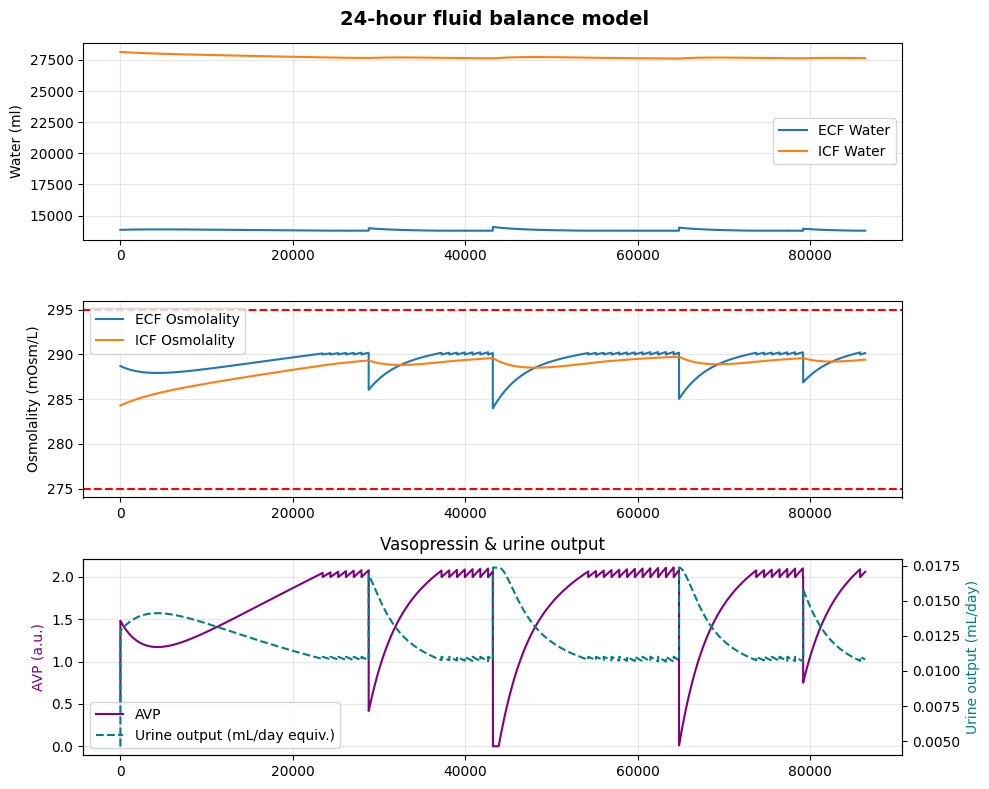

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initialise model variables
water = 42000
salt = 117
water_ECF = 0.33 * water
water_ICF = 0.67 * water
osm_ECF = 34.2 * salt
osm_ICF = 8000
min_osmo = 275
max_osmo = 295

# Set control parameters
runtime = 86400

# Set model parameters
ktrans = 0.01
kv=0.4
R_k=2
R_n=2
AVPthre=285
Umin=400/runtime
Umax=1500/runtime
water_loss = 750
water_loss = water_loss / 86400

water_ECF_data = np.empty(runtime + 1)
water_ICF_data = np.empty(runtime + 1)
osm_ECF_data = np.empty(runtime + 1)
osm_ICF_data = np.empty(runtime + 1)
osmo_ECF_data = np.empty(runtime + 1)
osmo_ICF_data = np.empty(runtime + 1)
AVP_data = np.zeros(runtime + 1)
urine_data = np.zeros(runtime + 1)

# Initialise recording arrays
water_ECF_data[0] = water_ECF
water_ICF_data[0] = water_ICF
osm_ECF_data[0] = osm_ECF
osm_ICF_data[0] = osm_ICF
osmo_ECF_data[0] = osm_ECF / (water_ECF / 1000)
osmo_ICF_data[0] = osm_ICF / (water_ICF / 1000)
urine_data[0] = Umin
AVP_data[0] = 0

#drinking events
drinking={8*3600:200,
          12*3600:300,
          18*3600:250,
          22*3600:150}

#thirsty-drinking events
thirsty_thre=290
thirsty_delay=900
k_thirsty=30
last_thirsty_drink=-thirsty_delay

# Run model loop
for i in range(1, runtime + 1):

    # Check for drinking events
    if i in drinking.keys():
        water_intake = drinking[i]
    else:
        water_intake = 0

    #check for thirst-driven drinking
    if osmo_ECF_data[i-1] > thirsty_thre and (i - last_thirsty_drink) > thirsty_delay:
        water_intake += k_thirsty * (osmo_ECF_data[i-1] - thirsty_thre)
        last_thirsty_drink = i
    else: water_intake += 0

    #vesopressin
    if osmo_ECF_data[i-1] > AVPthre:
        AVP_data[i] = kv*(osmo_ECF_data[i-1] - AVPthre)
    else:       AVP_data[i] = 0
    Rv=AVP_data[i]**R_n/(AVP_data[i]**R_n+R_k**R_n)
    Uw=Umin+(1-Rv)*(Umax-Umin)

    osmo_ECF = osm_ECF / (water_ECF / 1000)
    osmo_ICF = osm_ICF / (water_ICF / 1000)
    water_trans = ktrans * (osmo_ECF - osmo_ICF)
    water_ECF = water_ECF + water_trans - water_loss - Uw + water_intake
    if water_ECF < 0: water_ECF = 0
    water_ICF = water_ICF - water_trans
    osm_ECF = osm_ECF + 0
    water_ECF_data[i] = water_ECF
    water_ICF_data[i] = water_ICF
    osm_ECF_data[i] = osm_ECF
    osm_ICF_data[i] = osm_ICF
    osmo_ECF_data[i] = osmo_ECF
    osmo_ICF_data[i] = osmo_ICF
    urine_data[i]=Uw
    
# Plot results
fig,axes = plt.subplots(3,1,figsize=(10,8))
fig.suptitle("24-hour fluid balance model", fontsize=14, fontweight="bold")

axes[0].plot(water_ECF_data, label='ECF Water')
axes[0].plot(water_ICF_data, label='ICF Water')
axes[0].set_ylabel('Water (ml)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(osmo_ECF_data, label='ECF Osmolality')
axes[1].plot(osmo_ICF_data, label='ICF Osmolality')
axes[1].set_ylabel('Osmolality (mOsm/L)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=min_osmo,color='r', linestyle='--', label='Min normal Osmolality')
axes[1].axhline(y=max_osmo,color='r', linestyle='--', label='Max normal Osmolality')

ax = axes[2]
ax2 = ax.twinx()
ax.plot(AVP_data, color="purple", label="AVP")
ax2.plot(urine_data, color="teal", linestyle="--", label="Urine output (mL/day equiv.)")
ax.set_ylabel("AVP (a.u.)", color="purple")
ax2.set_ylabel("Urine output (mL/day)", color="teal")
ax.set_title("Vasopressin & urine output")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

next lets set a gut water storage to make the ECF volume changes more smoothly.

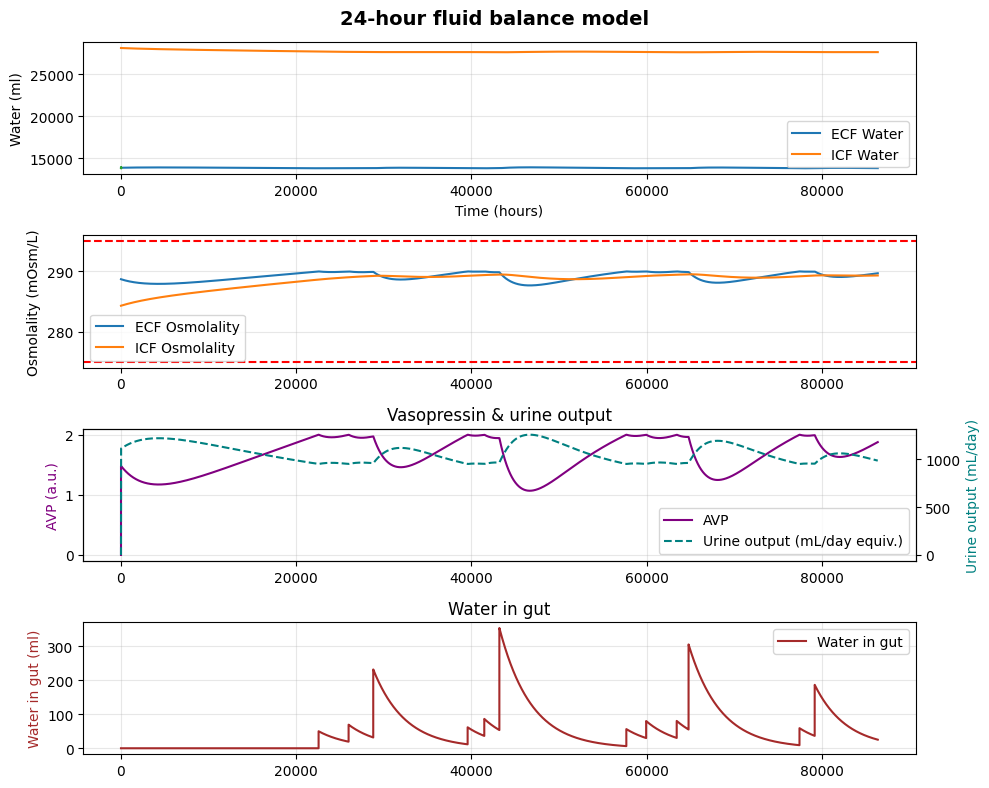

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Initialise model variables
water = 42000
salt = 117
water_ECF = 0.33 * water
water_ICF = 0.67 * water
osm_ECF = 34.2 * salt
osm_ICF = 8000
min_osmo = 275
max_osmo = 295

# Set control parameters
runtime = 86400

# Set model parameters
ktrans = 0.01
kv=0.4
R_k=2
R_n=2
AVPthre=285
Umin=400/runtime
Umax=1500/runtime
water_loss = 750
water_loss = water_loss / 86400

water_ECF_data = np.empty(runtime + 1)
water_ICF_data = np.empty(runtime + 1)
osm_ECF_data = np.empty(runtime + 1)
osm_ICF_data = np.empty(runtime + 1)
osmo_ECF_data = np.empty(runtime + 1)
osmo_ICF_data = np.empty(runtime + 1)
AVP_data = np.zeros(runtime + 1)
urine_data = np.zeros(runtime + 1)
drink_events = np.zeros(runtime + 1)
water_gut_data = np.zeros(runtime + 1)

# Initialise recording arrays
water_ECF_data[0] = water_ECF
water_ICF_data[0] = water_ICF
osm_ECF_data[0] = osm_ECF
osm_ICF_data[0] = osm_ICF
osmo_ECF_data[0] = osm_ECF / (water_ECF / 1000)
osmo_ICF_data[0] = osm_ICF / (water_ICF / 1000)
urine_data[0] = Umin
AVP_data[0] = 0
water_gut_data[0] = 0

#drinking events
drinking={8*3600:200,
          12*3600:300,
          18*3600:250,
          22*3600:150}

#thirsty-drinking events
thirsty_thre=290
thirsty_delay=900
k_thirsty=30
last_thirsty_drink=-thirsty_delay
drinking_baseline=50

#gut water storage and absorption
water_gut=0
k_gut= 0.5/1800

# Run model loop
for i in range(1, runtime + 1):

    # Check for drinking events
    if i in drinking.keys():
        water_intake = drinking[i]
        drink_events[i] = drinking[i]
        water_gut += drinking[i]
    else:
        water_intake = 0

    #check for thirst-driven drinking
    if osmo_ECF_data[i-1] > thirsty_thre and (i - last_thirsty_drink) > thirsty_delay:
        thirsty_drink=k_thirsty * (osmo_ECF_data[i-1] - thirsty_thre) + drinking_baseline
        water_intake += thirsty_drink
        last_thirsty_drink = i
        drink_events[i] += thirsty_drink
        water_gut += thirsty_drink
    else: water_intake += 0

    #vesopressin
    if osmo_ECF_data[i-1] > AVPthre:
        AVP_data[i] = kv*(osmo_ECF_data[i-1] - AVPthre)
    else:       AVP_data[i] = 0
    Rv=AVP_data[i]**R_n/(AVP_data[i]**R_n+R_k**R_n)
    Uw=Umin+(1-Rv)*(Umax-Umin)

    absorbed_gut = k_gut * water_gut
    osmo_ECF = osm_ECF / (water_ECF / 1000)
    osmo_ICF = osm_ICF / (water_ICF / 1000)
    water_trans = ktrans * (osmo_ECF - osmo_ICF)
    water_ECF = water_ECF + water_trans - water_loss - Uw + absorbed_gut
    if water_ECF < 0: water_ECF = 0
    water_ICF = water_ICF - water_trans
    osm_ECF = osm_ECF + 0
    water_ECF_data[i] = water_ECF
    water_ICF_data[i] = water_ICF
    osm_ECF_data[i] = osm_ECF
    osm_ICF_data[i] = osm_ICF
    osmo_ECF_data[i] = osmo_ECF
    osmo_ICF_data[i] = osmo_ICF
    urine_data[i]=Uw*runtime
    water_gut_data[i] = water_gut - absorbed_gut
    water_gut -= absorbed_gut
    
# Plot results
fig,axes = plt.subplots(4,1,figsize=(10,8))
fig.suptitle("24-hour fluid balance model", fontsize=14, fontweight="bold")

t_hours = np.linspace(0, 24, runtime + 1)
axes[0].plot(water_ECF_data, label='ECF Water')
axes[0].plot(water_ICF_data, label='ICF Water')
axes[0].set_ylabel('Water (ml)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].plot(t_hours, water_ECF_data)
axes[0].set_xlabel("Time (hours)")

axes[1].plot(osmo_ECF_data, label='ECF Osmolality')
axes[1].plot(osmo_ICF_data, label='ICF Osmolality')
axes[1].set_ylabel('Osmolality (mOsm/L)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=min_osmo,color='r', linestyle='--', label='Min normal Osmolality')
axes[1].axhline(y=max_osmo,color='r', linestyle='--', label='Max normal Osmolality')

ax = axes[2]
ax2 = ax.twinx()
ax.plot(AVP_data, color="purple", label="AVP")
ax2.plot(urine_data, color="teal", linestyle="--", label="Urine output (mL/day equiv.)")
ax.set_ylabel("AVP (a.u.)", color="purple")
ax2.set_ylabel("Urine output (mL/day)", color="teal")
ax.set_title("Vasopressin & urine output")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)
ax.grid(True, alpha=0.3)

ax = axes[3]
ax.plot(water_gut_data, color="brown", label="Water in gut")
ax.set_ylabel("Water in gut (ml)", color="brown")
ax.set_title("Water in gut")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()